In [32]:
import pandas as pd
df = pd.read_csv("data/tweets.csv")
df.head(5)

,handle,id,text,created_at,likes,retweets,url
0,ShahBalen,2079489463831650494,निजी शिक्षा र स्वास्थ्य क्षेत्रमा लगाइएको ३% स...,Tue Jul 21 08:51:37 +0000 2026,1832,229,https://x.com/ShahBalen/status/207948946383165...
1,ShahBalen,2068338604640985505,ललितपुरमा मनाइने भोटोजात्रा !! https://t.co/mQ...,Sat Jun 20 14:22:05 +0000 2026,2265,133,https://x.com/ShahBalen/status/206833860464098...
2,ShahBalen,2068197406488027550,MAKALU BASE CAMP TREK \n\nMakalu Barun Valley ...,Sat Jun 20 05:01:01 +0000 2026,3256,489,https://x.com/ShahBalen/status/206819740648802...
3,ShahBalen,2066168158403403978,"PM , HM , IM :) https://t.co/JqsC80BeyE",Sun Jun 14 14:37:31 +0000 2026,5221,283,https://x.com/ShahBalen/status/206616815840340...
4,ShahBalen,2055948372129771914,World record 32 times Mount Everest climb.\nवि...,Sun May 17 09:47:44 +0000 2026,3257,367,https://x.com/ShahBalen/status/205594837212977...


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9931 entries, 0 to 9930
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   handle      9931 non-null   object
 1   id          9931 non-null   int64 
 2   text        9931 non-null   object
 3   created_at  9931 non-null   object
 4   likes       9931 non-null   int64 
 5   retweets    9931 non-null   int64 
 6   url         9931 non-null   object
dtypes: int64(3), object(4)
memory usage: 543.2+ KB


In [34]:
df.describe()

,id,likes,retweets
count,9.931000e+03,9931.000000,9931.000000
mean,1.884131e+18,309.518679,117.769409
std,1.844350e+17,919.516196,2175.347488
min,9.405697e+17,0.000000,0.000000
25%,1.764769e+18,0.000000,3.000000
50%,1.950373e+18,63.000000,8.000000
75%,2.031036e+18,222.000000,26.000000
max,2.092847e+18,25461.000000,118955.000000


We remove all the nepali ones: removed 2829 ones

In [35]:
def contains_nepali(text):
    if not isinstance(text, str) or not text.strip():
        return False
    return any(0x0900 <= ord(ch) <= 0x097F for ch in text)

df_filtered = df[df["text"].apply(contains_nepali)].reset_index(drop=True)

print(f"Kept {len(df_filtered)} of {len(df)} tweets")
df_filtered.head(5)

Kept 7102 of 9931 tweets


,handle,id,text,created_at,likes,retweets,url
0,ShahBalen,2079489463831650494,निजी शिक्षा र स्वास्थ्य क्षेत्रमा लगाइएको ३% स...,Tue Jul 21 08:51:37 +0000 2026,1832,229,https://x.com/ShahBalen/status/207948946383165...
1,ShahBalen,2068338604640985505,ललितपुरमा मनाइने भोटोजात्रा !! https://t.co/mQ...,Sat Jun 20 14:22:05 +0000 2026,2265,133,https://x.com/ShahBalen/status/206833860464098...
2,ShahBalen,2055948372129771914,World record 32 times Mount Everest climb.\nवि...,Sun May 17 09:47:44 +0000 2026,3257,367,https://x.com/ShahBalen/status/205594837212977...
3,ShahBalen,2051506575588852104,"धेरै पत्रकार, नेता, अभियन्ता, व्यापारी र आम जन...",Tue May 05 03:37:37 +0000 2026,3432,621,https://x.com/ShahBalen/status/205150657558885...
4,ShahBalen,2051143466277818515,काठमाडौँ उपत्यकाका नदीकिनार तथा सरकारी स्वामित...,Mon May 04 03:34:45 +0000 2026,2779,445,https://x.com/ShahBalen/status/205114346627781...


In [36]:
import re

DEVANAGARI_RUN = re.compile(r"[\u0900-\u097F]+")

def extract_nepali_only(text):
    """Extract only Devanagari characters/runs from a string, dropping
    any English letters, digits, or punctuation — even mid-word."""
    if not isinstance(text, str):
        return ""
    runs = DEVANAGARI_RUN.findall(text)
    return " ".join(runs)


df_filtered["text_nepali_only"] = df_filtered["text"].apply(extract_nepali_only)
print(f"Kept {len(df_filtered)} of {len(df_filtered)} tweets")
df_filtered.head(5)

Kept 7102 of 7102 tweets


,handle,id,text,created_at,likes,retweets,url,text_nepali_only
0,ShahBalen,2079489463831650494,निजी शिक्षा र स्वास्थ्य क्षेत्रमा लगाइएको ३% स...,Tue Jul 21 08:51:37 +0000 2026,1832,229,https://x.com/ShahBalen/status/207948946383165...,निजी शिक्षा र स्वास्थ्य क्षेत्रमा लगाइएको ३ सम...
1,ShahBalen,2068338604640985505,ललितपुरमा मनाइने भोटोजात्रा !! https://t.co/mQ...,Sat Jun 20 14:22:05 +0000 2026,2265,133,https://x.com/ShahBalen/status/206833860464098...,ललितपुरमा मनाइने भोटोजात्रा
2,ShahBalen,2055948372129771914,World record 32 times Mount Everest climb.\nवि...,Sun May 17 09:47:44 +0000 2026,3257,367,https://x.com/ShahBalen/status/205594837212977...,विश्वको सर्वोच्च शिखर सगरमाथा केवल एउटा भौगोलि...
3,ShahBalen,2051506575588852104,"धेरै पत्रकार, नेता, अभियन्ता, व्यापारी र आम जन...",Tue May 05 03:37:37 +0000 2026,3432,621,https://x.com/ShahBalen/status/205150657558885...,धेरै पत्रकार नेता अभियन्ता व्यापारी र आम जनताल...
4,ShahBalen,2051143466277818515,काठमाडौँ उपत्यकाका नदीकिनार तथा सरकारी स्वामित...,Mon May 04 03:34:45 +0000 2026,2779,445,https://x.com/ShahBalen/status/205114346627781...,काठमाडौँ उपत्यकाका नदीकिनार तथा सरकारी स्वामित...


In [37]:
import re

LATIN_CHAR = re.compile(r"[A-Za-z]")
DEVANAGARI_CHAR = re.compile(r"[\u0900-\u097F]")
URL_PATTERN = re.compile(r"https?://\S+")

def has_both_scripts(text):
    if not isinstance(text, str):
        return False
    return bool(LATIN_CHAR.search(text)) and bool(DEVANAGARI_CHAR.search(text))

def has_url(text):
    if not isinstance(text, str):
        return False
    return bool(URL_PATTERN.search(text))

df_filtered["has_mixed_script"] = df_filtered["text"].apply(has_both_scripts)
df_filtered["has_url"] = df_filtered["text"].apply(has_url)

mixed_count = df_filtered["has_mixed_script"].sum()
url_count = df_filtered["has_url"].sum()
mixed_and_url = (df_filtered["has_mixed_script"] & df_filtered["has_url"]).sum()

print(f"{mixed_count} of {len(df_filtered)} tweets contained both Nepali and English")
print(f"{url_count} of {len(df_filtered)} tweets contained an http(s) link")
print(f"{mixed_and_url} of {mixed_count} mixed-script tweets also contained a link")

5803 of 7102 tweets contained both Nepali and English
4510 of 7102 tweets contained an http(s) link
4510 of 5803 mixed-script tweets also contained a link


In [38]:
import re

LATIN_CHAR = re.compile(r"[A-Za-z]")

def is_nepali_only(text):
    """Returns True if the string contains no Latin letters at all
    (Devanagari, spaces, digits, and punctuation are fine)."""
    if not isinstance(text, str):
        return False
    return not LATIN_CHAR.search(text)


# Test it against the column
df_filtered["is_valid_nepali_only"] = df_filtered["text_nepali_only"].apply(is_nepali_only)

# Any rows that failed the check (i.e. still contain English letters)
failed = df_filtered[~df_filtered["is_valid_nepali_only"]]
print(f"{len(failed)} of {len(df_filtered)} rows still contain Latin characters")
failed[["text", "text_nepali_only"]].head(10)

0 of 7102 rows still contain Latin characters


,text,text_nepali_only


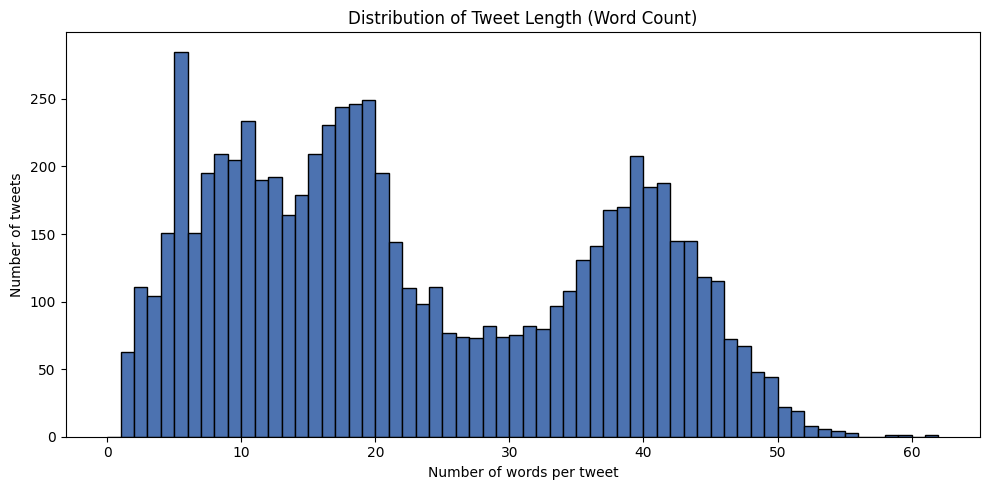

count    7102.000000
mean       22.698536
std        13.788939
min         1.000000
25%        11.000000
50%        19.000000
75%        36.000000
max        61.000000
Name: word_count, dtype: float64


In [39]:
import matplotlib.pyplot as plt

# Word count per tweet (using the Nepali-only cleaned text)
df_filtered["word_count"] = df_filtered["text_nepali_only"].apply(
    lambda t: len(t.split()) if isinstance(t, str) else 0
)

plt.figure(figsize=(10, 5))
plt.hist(df_filtered["word_count"], bins=range(0, df_filtered["word_count"].max() + 2), 
         edgecolor="black", color="#4C72B0")
plt.xlabel("Number of words per tweet")
plt.ylabel("Number of tweets")
plt.title("Distribution of Tweet Length (Word Count)")
plt.tight_layout()
plt.show()

print(df_filtered["word_count"].describe())

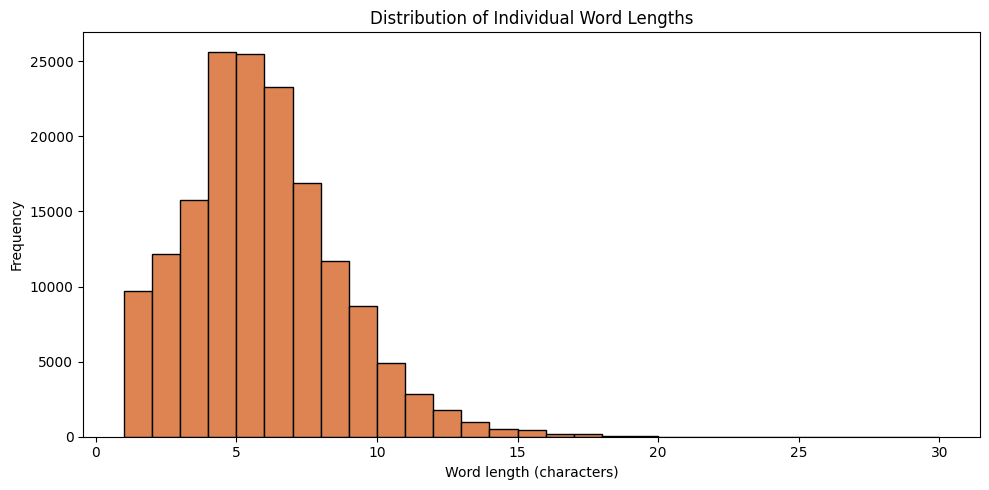

count    161205.000000
mean          5.440942
std           2.710729
min           1.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          29.000000
Name: text_nepali_only, dtype: float64


In [40]:
# Length of individual words across all tweets
all_words = df_filtered["text_nepali_only"].dropna().str.split().explode()
word_lengths = all_words.str.len()

plt.figure(figsize=(10, 5))
plt.hist(word_lengths, bins=range(1, word_lengths.max() + 2), 
         edgecolor="black", color="#DD8452")
plt.xlabel("Word length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Individual Word Lengths")
plt.tight_layout()
plt.show()

print(word_lengths.describe())

In [41]:
# Top 10 longest words, deduplicated
top_longest = (
    pd.DataFrame({"word": all_words, "length": word_lengths})
    .drop_duplicates(subset="word")
    .sort_values("length", ascending=False)
    .head(50)
)
print(top_longest)

                               word  length
974   डमड्डमड्डमड्डमनिनादवड्डमर्वयं      29
585         शुभकामना।काँग्रेसीहरूले      23
758          जोगिन्छ।।सुत्केरीहरुको      22
6216          कालेकालेमिलेरखाँउभाले      21
4073          कल्याणकारीप्रजातन्त्र      21
3740          पूर्वप्रधानमन्त्रीहरू      21
203           स्वास्थ्यकर्मीहरूमाथि      21
3662          विचारभन्दामाथिमित्रता      21
6348          अनुसन्धानकर्ताज्युहरू      21
6345          अनुसन्धानकर्ताज्युहरु      21
6612           पूर्वप्रधानन्यायाधीश      20
375            हुनुहुन्छ।साथीहरूलाई      20
3579           भिक्षुव्यापारविद्रोह      20
1856           पूर्वउपप्रधानमन्त्री      20
6022           राष्ट्राध्यक्षहरुलाई      20
1462           पूर्वप्रधानमन्त्रीका      20
130            स्वास्थ्यकर्मीहरुबाट      20
2769           लगाईन्थ्यो।काठमाडौमा      20
498            बौद्धधर्मालम्बीहरुमा      20
429             धर्मावलम्बीहरूप्रति      19
4451            पदाधिकारीहरूविरुद्ध      19
2978            बर्दघाटवासीहरूप्

In [42]:
df_filtered = df_filtered[df_filtered["word_count"] >= 4].reset_index(drop=True)

print(f"Kept {len(df_filtered)} tweets with 4+ words")
print(df_filtered["word_count"].describe())

Kept 6824 tweets with 4+ words
count    6824.000000
mean       23.535756
std        13.414503
min         4.000000
25%        12.000000
50%        20.000000
75%        37.000000
max        61.000000
Name: word_count, dtype: float64


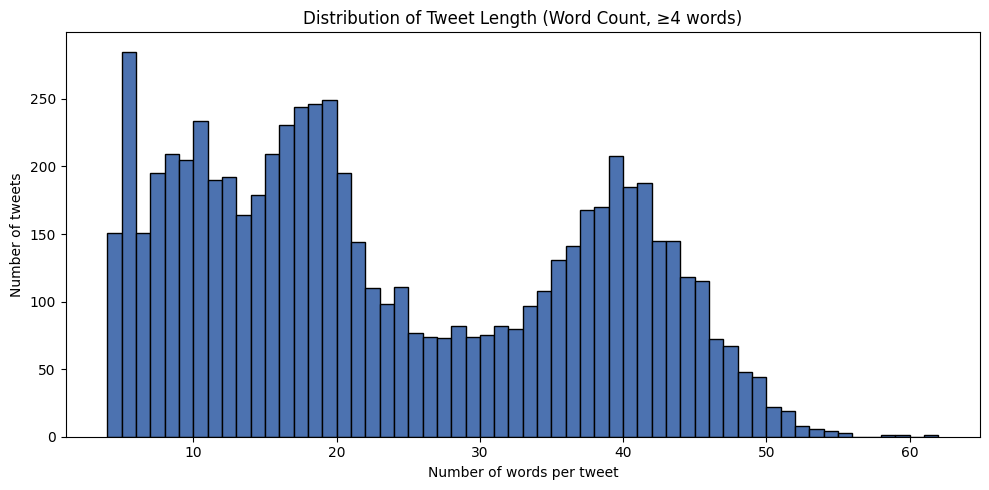

In [43]:
plt.figure(figsize=(10, 5))
plt.hist(df_filtered["word_count"], bins=range(4, df_filtered["word_count"].max() + 2), 
         edgecolor="black", color="#4C72B0")
plt.xlabel("Number of words per tweet")
plt.ylabel("Number of tweets")
plt.title("Distribution of Tweet Length (Word Count, ≥4 words)")
plt.tight_layout()
plt.show()

In [44]:
df_filtered

,handle,id,text,created_at,likes,retweets,url,text_nepali_only,has_mixed_script,has_url,is_valid_nepali_only,word_count
0,ShahBalen,2079489463831650494,निजी शिक्षा र स्वास्थ्य क्षेत्रमा लगाइएको ३% स...,Tue Jul 21 08:51:37 +0000 2026,1832,229,https://x.com/ShahBalen/status/207948946383165...,निजी शिक्षा र स्वास्थ्य क्षेत्रमा लगाइएको ३ सम...,True,True,True,44
1,ShahBalen,2055948372129771914,World record 32 times Mount Everest climb.\nवि...,Sun May 17 09:47:44 +0000 2026,3257,367,https://x.com/ShahBalen/status/205594837212977...,विश्वको सर्वोच्च शिखर सगरमाथा केवल एउटा भौगोलि...,True,True,True,34
2,ShahBalen,2051506575588852104,"धेरै पत्रकार, नेता, अभियन्ता, व्यापारी र आम जन...",Tue May 05 03:37:37 +0000 2026,3432,621,https://x.com/ShahBalen/status/205150657558885...,धेरै पत्रकार नेता अभियन्ता व्यापारी र आम जनताल...,False,False,True,40
3,ShahBalen,2051143466277818515,काठमाडौँ उपत्यकाका नदीकिनार तथा सरकारी स्वामित...,Mon May 04 03:34:45 +0000 2026,2779,445,https://x.com/ShahBalen/status/205114346627781...,काठमाडौँ उपत्यकाका नदीकिनार तथा सरकारी स्वामित...,False,False,True,35
4,ShahBalen,2050070598173548852,"बुद्धले भन्नुभयो “दुःख छ, दुःखको कारण छ, दुःखक...",Fri May 01 04:31:33 +0000 2026,4632,619,https://x.com/ShahBalen/status/205007059817354...,बुद्धले भन्नुभयो दुःख छ दुःखको कारण छ दुःखको न...,True,True,True,42
...,...,...,...,...,...,...,...,...,...,...,...,...
6819,RishiDhamala,1496361344182132736,नेकपा एमालेका नेता खगराज अधिकारीले होहल्लाका ब...,Wed Feb 23 05:48:40 +0000 2022,0,0,https://x.com/RishiDhamala/status/149636134418...,नेकपा एमालेका नेता खगराज अधिकारीले होहल्लाका ब...,True,True,True,16
6820,RishiDhamala,1496351281287675904,अमेरिकी सहयोग परियोजना एमसीसीको बारेमा छलफल गर...,Wed Feb 23 05:08:40 +0000 2022,1,0,https://x.com/RishiDhamala/status/149635128128...,अमेरिकी सहयोग परियोजना एमसीसीको बारेमा छलफल गर...,True,True,True,19
6821,RishiDhamala,1496350690272485376,गृहमन्त्री खाँड नेकपा (एमाले) अध्यक्ष केपी शर्...,Wed Feb 23 05:06:20 +0000 2022,3,0,https://x.com/RishiDhamala/status/149635069027...,गृहमन्त्री खाँड नेकपा एमाले अध्यक्ष केपी शर्मा...,True,True,True,13
6822,RishiDhamala,1496347725218349058,गृहमन्त्री बालकृष्ण खाँणले नेकपा (माओवादी केन्...,Wed Feb 23 04:54:33 +0000 2022,1,0,https://x.com/RishiDhamala/status/149634772521...,गृहमन्त्री बालकृष्ण खाँणले नेकपा माओवादी केन्द...,True,True,True,14


In [45]:
df_filtered.to_csv("filtered_data.csv", index=False)
print(f"Saved {len(df_filtered)} rows to filtered_data.csv")

Saved 6824 rows to filtered_data.csv
